In [16]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/yaqoobkhawaja/genz-data/genz_social_media_usage_1M.csv


# TASK 1  STARTED FROM HERE

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("/kaggle/input/datasets/yaqoobkhawaja/genz-data/genz_social_media_usage_1M.csv")


In [5]:
df.head()


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ MB


In [7]:
df.isnull().sum()


age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [9]:
df = df.drop_duplicates()

In [10]:
# numeric columns → fill with mean
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))


In [11]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# remove extra spaces in text
for col in cat_cols:
    df[col] = df[col].str.strip()
    

In [12]:
df.isnull().sum()


age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [13]:
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [17]:
df.to_csv("/kaggle/working/cleaned_genz_data.csv", index=False)

# TASk 2 started from here

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("/kaggle/working/cleaned_genz_data.csv")

In [20]:
df.describe()


,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


In [21]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.max(numeric_only=True)
df.min(numeric_only=True)

age                         13.0
daily_usage_hours            0.5
num_platforms_used           1.0
avg_session_minutes          5.0
night_usage                  0.0
mental_health_score          1.0
screen_time_before_sleep     0.0
dtype: float64

In [22]:
df.shape


(1000000, 12)

In [23]:
df.isnull().sum()

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [24]:
corr = df.corr(numeric_only=True)
corr


,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
age,1.000000,-0.001309,-0.000175,-0.000964,-0.000774,0.000903,-0.000149
daily_usage_hours,-0.001309,1.000000,-0.002328,0.001147,0.000023,-0.761665,0.000282
num_platforms_used,-0.000175,-0.002328,1.000000,0.000143,0.001893,0.002555,0.001658
avg_session_minutes,-0.000964,0.001147,0.000143,1.000000,-0.001826,-0.000162,-0.000273
night_usage,-0.000774,0.000023,0.001893,-0.001826,1.000000,-0.000124,0.001615
mental_health_score,0.000903,-0.761665,0.002555,-0.000162,-0.000124,1.000000,-0.000132
screen_time_before_sleep,-0.000149,0.000282,0.001658,-0.000273,0.001615,-0.000132,1.000000


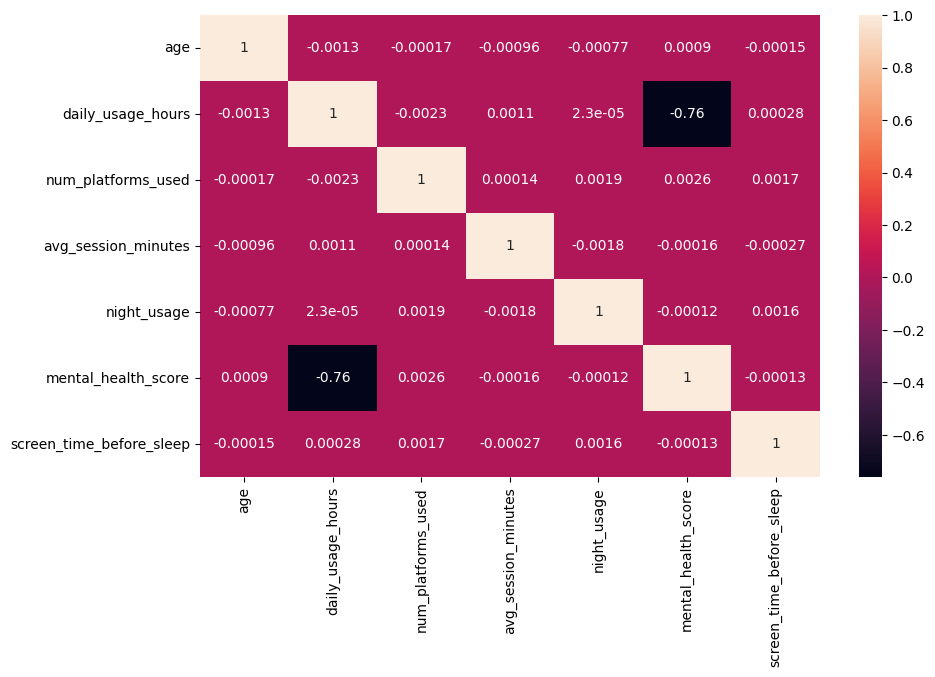

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

In [26]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(col, "Outliers:", len(outliers))

age Outliers: 0
daily_usage_hours Outliers: 3545
num_platforms_used Outliers: 0
avg_session_minutes Outliers: 3446
night_usage Outliers: 0
mental_health_score Outliers: 3595
screen_time_before_sleep Outliers: 3488


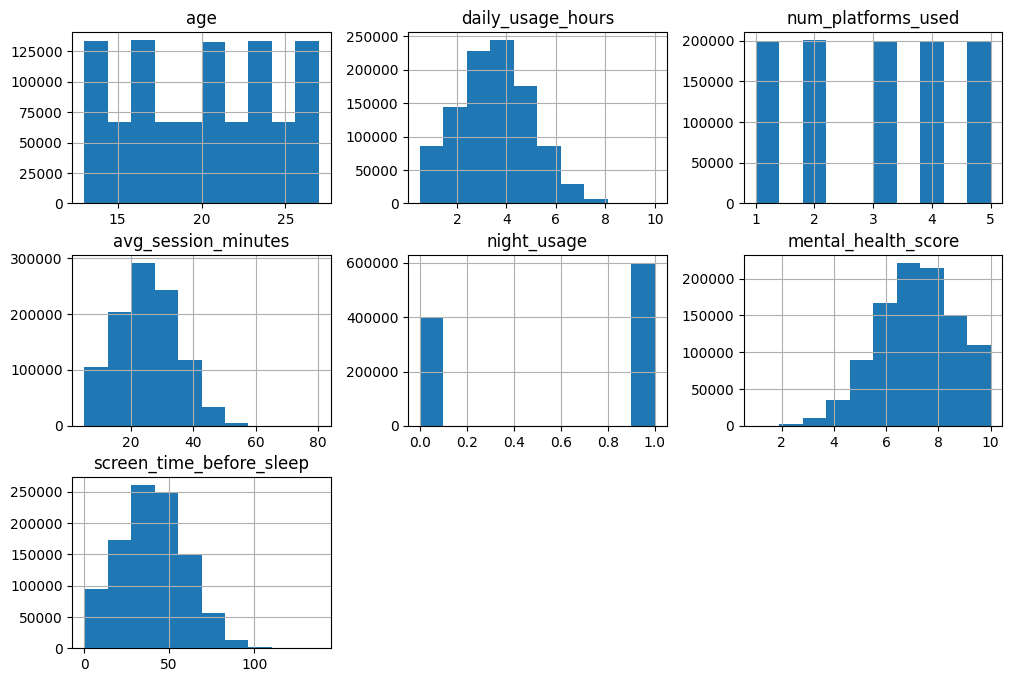

In [27]:
df.hist(figsize=(12,8))
plt.show()

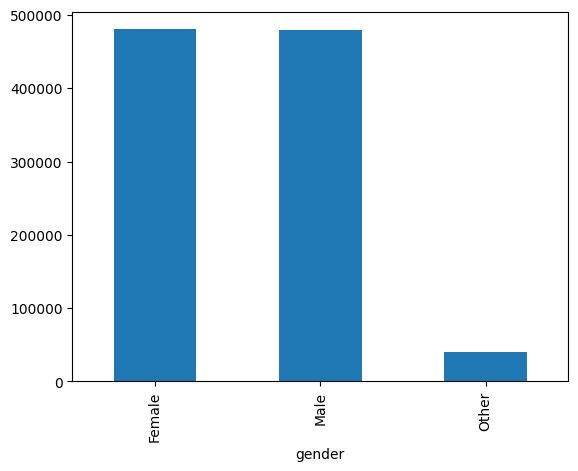

In [28]:
col = df.select_dtypes(include='object').columns[0]
df[col].value_counts().head(10).plot(kind='bar')
plt.show()

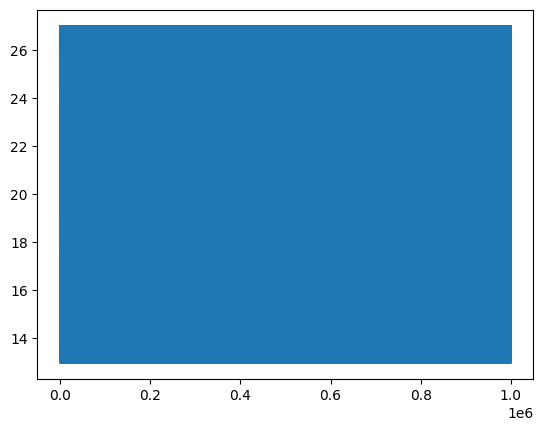

In [29]:
num_col = df.select_dtypes(include=['int64','float64']).columns[0]
df[num_col].plot(kind='line')
plt.show()

In [30]:
df.describe(include='all')

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
count,1000000.000000,1000000,1000000,1000000.000000,1000000,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000
unique,NaN,3,7,NaN,5,NaN,5,NaN,NaN,NaN,3,NaN
top,NaN,Female,India,NaN,Instagram,NaN,Entertainment,NaN,NaN,NaN,Medium,NaN
freq,NaN,480113,350321,NaN,299927,NaN,400052,NaN,NaN,NaN,589843,NaN
mean,19.994629,NaN,NaN,3.514998,NaN,2.999469,NaN,25.088819,0.599958,7.170671,NaN,40.120754
std,4.322119,NaN,NaN,1.468771,NaN,1.414598,NaN,9.794249,0.489907,1.503885,NaN,19.569847
min,13.000000,NaN,NaN,0.500000,NaN,1.000000,NaN,5.000000,0.000000,1.000000,NaN,0.000000
25%,16.000000,NaN,NaN,2.493985,NaN,2.000000,NaN,18.257267,0.000000,6.147371,NaN,26.459592
50%,20.000000,NaN,NaN,3.503302,NaN,3.000000,NaN,25.002480,1.000000,7.198098,NaN,39.977162
75%,24.000000,NaN,NaN,4.513016,NaN,4.000000,NaN,31.759257,1.000000,8.243818,NaN,53.424345
